In [28]:
import logging
import os

# Define the log file path
log_file_path = 'colab_log.log'

# Remove existing log file if it exists to ensure a fresh log for each run
if os.path.exists(log_file_path):
    os.remove(log_file_path)

# Configure logging to a file
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_file_path)
    ]
)
logger = logging.getLogger(__name__)
logger.info('Logging setup complete. Messages will be written to colab_log.log')

In [29]:
import pandas as pd

try:
    data = pd.read_csv("virginia_air_quality_2024_2025_merged.csv")
    logger.info("Successfully loaded 'virginia_air_quality_2024_2025_merged.csv' into DataFrame.")
except FileNotFoundError:
    logger.error("Error: CSV file 'virginia_air_quality_2024_2025_merged.csv' not found. Please ensure the file is uploaded.")
    data = pd.DataFrame() # Initialize empty DataFrame to prevent further errors
except Exception as e:
    logger.error(f"An unexpected error occurred while loading the CSV: {e}")
    data = pd.DataFrame() # Initialize empty DataFrame

In [18]:
print(data.head())

         Date    Site ID  pm25   aqi     State        County  \
0  2024-01-01  510030001   4.4  24.0  Virginia     Albemarle   
1  2024-01-01  510130020   7.0  39.0  Virginia     Arlington   
2  2024-01-01  510360002   4.9  27.0  Virginia       Charles   
3  2024-01-01  510410004   5.1  28.0  Virginia  Chesterfield   
4  2024-01-01  510590030   9.7  52.0  Virginia       Fairfax   

                    Local Site Name  Site Latitude  Site Longitude  ozone  \
0             Albemarle High School       38.07657       -78.50397    NaN   
1      Aurora Hills Visitors Center       38.85770       -77.05922  0.019   
2                Shirley Plantation       37.34438       -77.25925    NaN   
3  VDOT Chesterfield Residency Shop       37.35748       -77.59355    NaN   
4                 Lee District Park       38.77335       -77.10468  0.020   

    no2  year  month  day  bad_air_day  
0   NaN  2024      1    1            0  
1  23.2  2024      1    1            0  
2   8.1  2024      1    1    

In [19]:
len(data)

12209

In [20]:
import sys
# Ensure pymongo is installed
!{sys.executable} -m pip install pymongo

In [30]:
from pymongo import MongoClient
from pymongo.errors import ConnectionFailure, OperationFailure

# MongoDB credentials are not included in this repository.
# Please see submission comments for the connection string.

# Replace with provided credentials
uri = "mongodb+srv://<username>:<password>@<cluster-url>/"

try:
    # Create MongoDB client
    client = MongoClient(uri)

    # Test connection
    client.admin.command('ping')
    print("Connected to MongoDB Atlas successfully!")

    # Access/create database
    db = client["air_quality"]

    # Access/create collection
    collection = db["virginia_data"]

    print("Database and collection ready.")

except ConnectionFailure as e:
    print(f"MongoDB connection failed: {e}")
except OperationFailure as e:
    print(f"MongoDB authentication or command failed: {e}")
except Exception as e:
    print(f"Unexpected error: {e}")

In [31]:
# Convert DataFrame to a list of dictionaries for MongoDB insertion
if 'data' in locals() and not data.empty:
    data_dict = data.to_dict(orient='records')
    try:
        # Insert the data into the collection
        insert_result = collection.insert_many(data_dict)
        logger.info(f"Inserted {len(insert_result.inserted_ids)} documents into the collection.")
        print(f"Inserted {len(insert_result.inserted_ids)} documents into the collection.")
    except OperationFailure as e:
        logger.error(f"MongoDB operation failed during data insertion: {e}")
        print(f"Error inserting data into MongoDB: {e}")
    except Exception as e:
        logger.error(f"An error occurred during data preparation/insertion to MongoDB: {e}")
        print(f"An error occurred during data insertion: {e}")
else:
    logger.warning("Data DataFrame is empty or not defined, skipping MongoDB insertion.")
    print("Data DataFrame is empty or not defined, skipping MongoDB insertion.")

Inserted 12209 documents into the collection.


In [32]:
# Define the target variable: (AQI > 50) Virginia has good air quality overall, wanted to make the threshold stricter so used AQI of 50 instead of 100
try:
    data['aqi_below_50'] = (data['aqi'] > 50).astype(int)
    logger.info("Target variable 'aqi_below_50' created successfully.")

    # Select features
    features = ['pm25', 'ozone', 'no2']
    X = data[features]
    y = data['aqi_below_50']
    logger.info("Features and target variable selected.")

    # Handle missing values in features (with mean)
    X = X.fillna(X.mean())
    logger.info("Missing values in features handled using mean imputation.")

    print("First 5 rows of features (X) after handling missing values:")
    display(X.head())
    print("First 5 values of target variable (y):")
    display(y.head())
except Exception as e:
    logger.error(f"Error during target variable definition or feature selection/handling: {e}")

First 5 rows of features (X) after handling missing values:


,pm25,ozone,no2
0,4.4,0.039343,16.294961
1,7.0,0.019000,23.200000
2,4.9,0.039343,8.100000
3,5.1,0.039343,16.294961
4,9.7,0.020000,16.294961


First 5 values of target variable (y):


,aqi_below_50
0,0
1,0
2,0
3,0
4,1


In [33]:
from sklearn.model_selection import train_test_split

try:
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    logger.info("Data split into training and testing sets successfully.")

    print(f"Shape of training features (X_train): {X_train.shape}")
    print(f"Shape of testing features (X_test): {X_test.shape}")
    print(f"Shape of training target (y_train): {y_train.shape}")
    print(f"Shape of testing target (y_test): {y_test.shape}")

    print("\nClass distribution in original target variable:")
    display(y.value_counts(normalize=True))
    print("\nClass distribution in training target variable:")
    display(y_train.value_counts(normalize=True))
    print("\nClass distribution in testing target variable:")
    display(y_test.value_counts(normalize=True))
except Exception as e:
    logger.error(f"Error during data splitting: {e}")

Shape of training features (X_train): (8546, 3)
Shape of testing features (X_test): (3663, 3)
Shape of training target (y_train): (8546,)
Shape of testing target (y_test): (3663,)

Class distribution in original target variable:


,proportion
aqi_below_50,
0,0.82988
1,0.17012



Class distribution in training target variable:


,proportion
aqi_below_50,
0,0.829862
1,0.170138



Class distribution in testing target variable:


,proportion
aqi_below_50,
0,0.829921
1,0.170079


Using a Logistic Regression model for classification, as it's a good baseline for binary classification tasks, simple yet effective algorithm for predicting the probability of a binary outcome.

In [34]:
from sklearn.linear_model import LogisticRegression

try:
    # Initialize the Logistic Regression model
    model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for small datasets and binary classification
    logger.info("Logistic Regression model initialized.")

    # Train the model on the training data
    model.fit(X_train, y_train)
    logger.info("Logistic Regression model trained successfully!")

    print("Logistic Regression model trained successfully!")
except Exception as e:
    logger.error(f"Error during Logistic Regression model training: {e}")

Logistic Regression model trained successfully!


Evaluating the trained model's performance on the test set using various metrics such as accuracy, precision, recall, F1-score, and the confusion matrix. These metrics will give a comprehensive understanding of how well the model predicts unhealthy air quality days.

Accuracy: 0.9929
Precision: 0.9950
Recall: 0.9631
F1-Score: 0.9788

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3040
           1       1.00      0.96      0.98       623

    accuracy                           0.99      3663
   macro avg       0.99      0.98      0.99      3663
weighted avg       0.99      0.99      0.99      3663



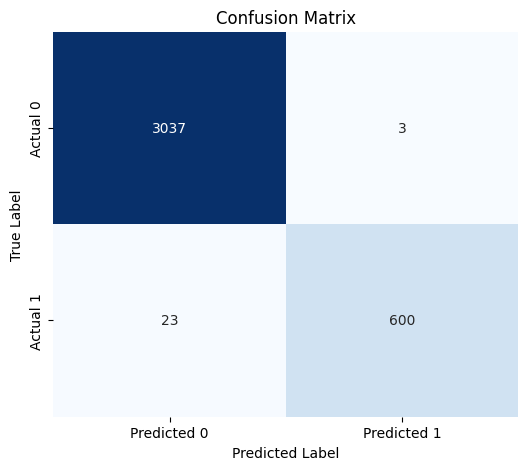

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    logger.info("Predictions made on the test set.")

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    logger.info("Model evaluation metrics calculated.")

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    # Display classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    logger.info("Confusion Matrix plotted and displayed.")
except Exception as e:
    logger.error(f"Error during model evaluation or plotting: {e}")

### Visualization Rationale: Confusion matrices are a crucial tool for evaluating the performance of a classification model, especially when dealing with imbalanced datasets. It provides a detailed breakdown of correct and incorrect predictions for each class. This visualization helped us understand the model's accuracy, precision, and recall in a more intuitive way than just looking at the numerical metrics, particularly highlighting how well the model identifies the positive class, or low quality air days.

For linear models like Logistic Regression, the coefficients of the features can be interpreted as their 'importance' or impact on the log-odds of the target variable. A positive coefficient indicates that as the feature value increases, the probability of a 'bad air day' increases. A negative coefficient indicates the opposite. The magnitude of the coefficient indicates the strength of this relationship.

/tmp/ipykernel_3446/549016574.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')


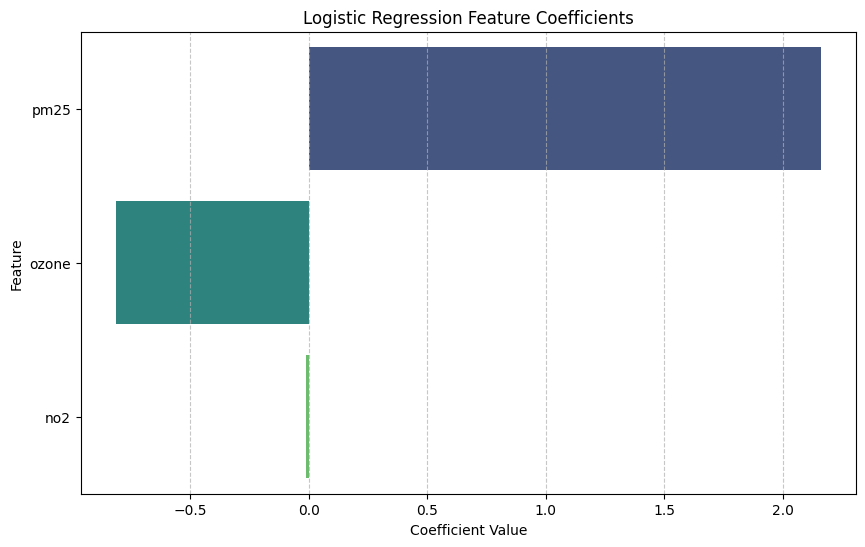

Feature Coefficients:


,Feature,Coefficient
0,pm25,2.159047
1,ozone,-0.813209
2,no2,-0.012523


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # Get the coefficients from the trained model
    coefficients = model.coef_[0]

    # Get the feature names
    feature_names = X.columns

    # Create a DataFrame for better visualization
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Sort by absolute coefficient value for better readability
    feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
    feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)
    logger.info("Feature coefficients extracted and prepared for visualization.")

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
    plt.title('Logistic Regression Feature Coefficients')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
    logger.info("Feature coefficients plot displayed.")

    print("Feature Coefficients:")
    display(feature_importance[['Feature', 'Coefficient']])
except Exception as e:
    logger.error(f"Error during feature importance analysis or plotting: {e}")

### Visualization Rationale: The coefficients associated with each feature provide direct insights into the feature's importance and its impact on the target variable. Visualizing these coefficients makes their relative magnitudes and directions easier to understand. This visualization was key to understanding which pollutants were most influential in predicting unhealthy air quality days according to our model, with PM2.5 standing out as the strongest positive driver.